In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [10]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')
sales = df.groupby('Order Date')['Sales'].sum().reset_index()
sales.set_index('Order Date', inplace=True)
monthly_sales = sales.resample('M').sum()
monthly_sales.head()

/tmp/ipykernel_7246/35630092.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales.resample('M').sum()


,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


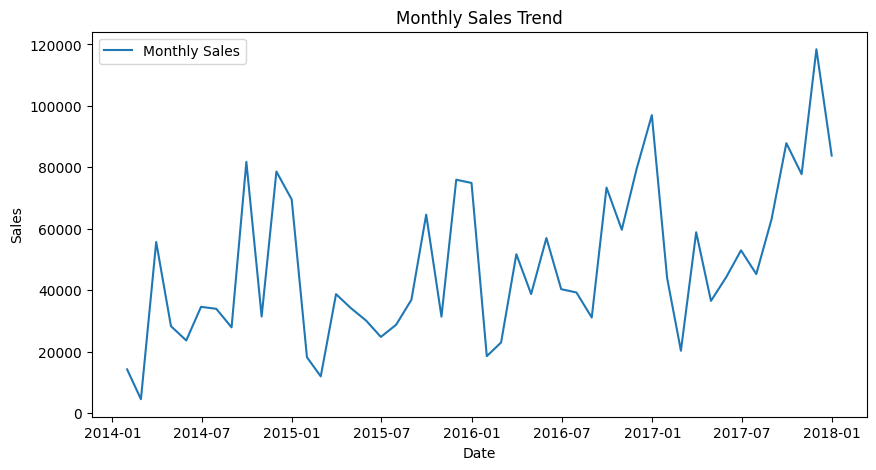

In [13]:
#Visualization of Historical Sales
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label="Monthly Sales")
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [15]:
train = monthly_sales[:-12]
test = monthly_sales[-12:]
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()
predictions = fit_model.forecast(12)
mae = mean_absolute_error(test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 11451.948652777099


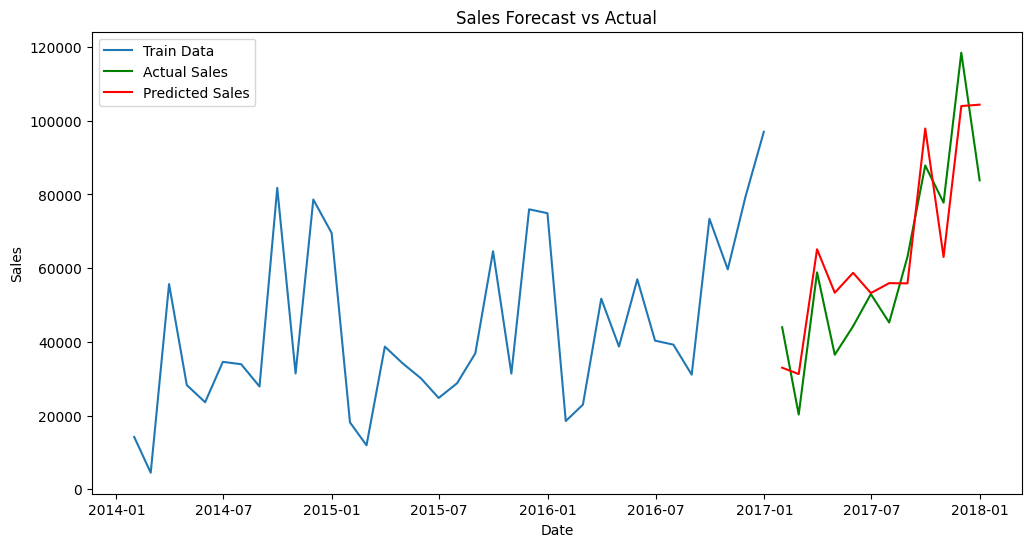

In [16]:
#Visualization of Forecast
plt.figure(figsize=(12,6))
plt.plot(train, label='Train Data')
plt.plot(test, label='Actual Sales', color='green')
plt.plot(predictions, label='Predicted Sales', color='red')
plt.title("Sales Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

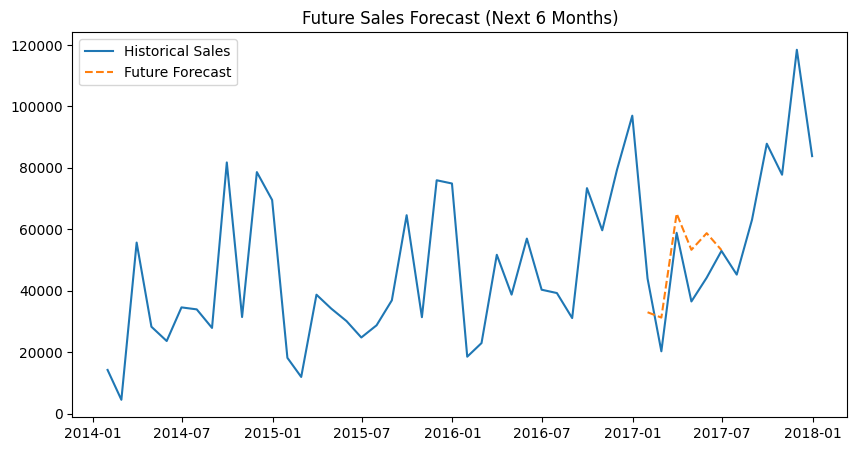

2017-01-31    33010.486032
2017-02-28    31275.311576
2017-03-31    65135.745312
2017-04-30    53337.770529
2017-05-31    58746.878756
2017-06-30    53248.533973
Freq: ME, dtype: float64


In [18]:
#Future Forecast (Next 6 Months)
future_forecast = fit_model.forecast(6)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label="Historical Sales")
plt.plot(future_forecast, label="Future Forecast", linestyle='dashed')

plt.title("Future Sales Forecast (Next 6 Months)")
plt.legend()
plt.show()

print(future_forecast)

/tmp/ipykernel_7246/3447284308.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


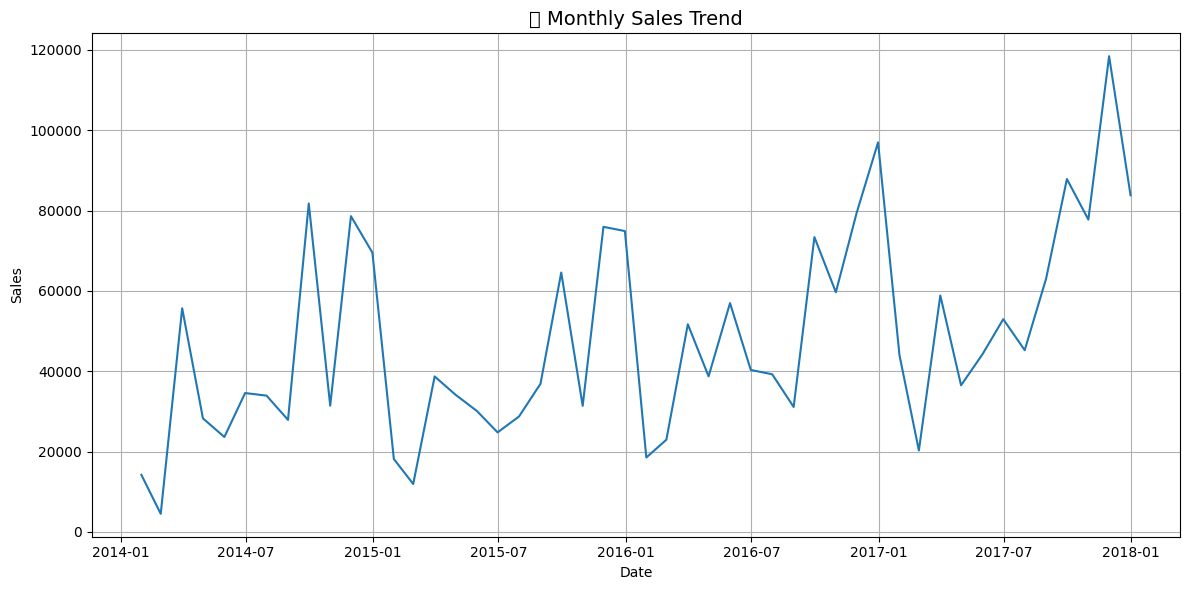

In [20]:
#1. Monthly Sales Trend
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("📈 Monthly Sales Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7246/770284920.py:11: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


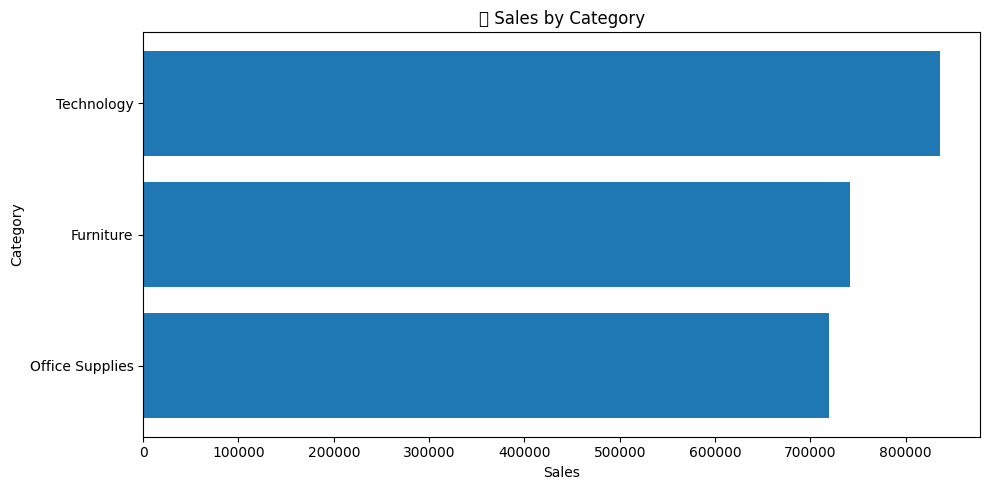

In [21]:
#2. Category-wise Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,5))
plt.barh(category_sales.index, category_sales.values)

plt.title("📦 Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


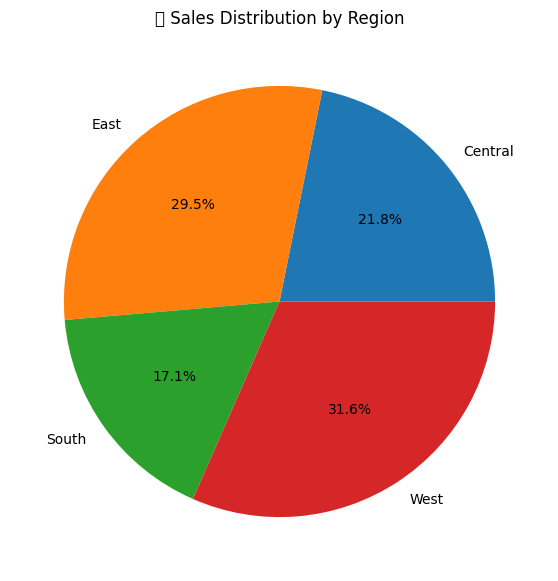

In [22]:
# region wise
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%')

plt.title("🌍 Sales Distribution by Region")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


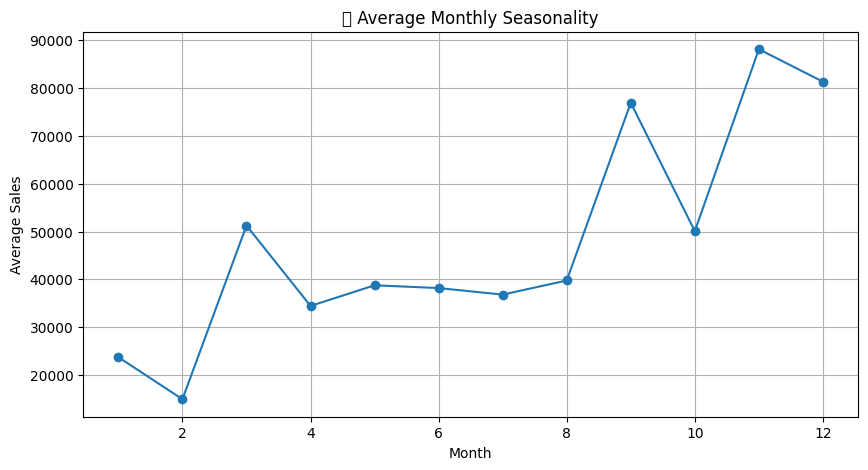

In [23]:
#monthly seasonal seasonality patterns
monthly_sales['Month'] = monthly_sales.index.month
seasonality = monthly_sales.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))
plt.plot(seasonality.index, seasonality.values, marker='o')

plt.title("📅 Average Monthly Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True)
plt.show()

In [24]:
# Forecast next 6 months
future_forecast = fit_model.forecast(6)
print("📊 Future Sales Forecast (Next 6 Months):")
print(future_forecast)

📊 Future Sales Forecast (Next 6 Months):
2017-01-31    33010.486032
2017-02-28    31275.311576
2017-03-31    65135.745312
2017-04-30    53337.770529
2017-05-31    58746.878756
2017-06-30    53248.533973
Freq: ME, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


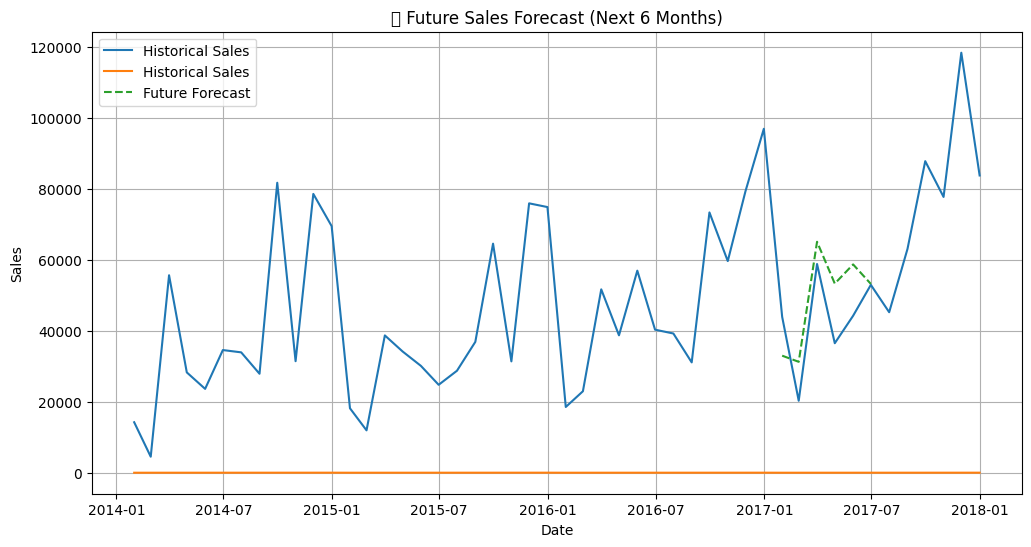

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Historical data
plt.plot(monthly_sales.index, monthly_sales.values, label='Historical Sales')

# Future forecast
plt.plot(future_forecast.index, future_forecast.values, linestyle='dashed', label='Future Forecast')

plt.title("🔮 Future Sales Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()